# Calculating catches from gridded DBPM outputs
**Author**: Denisse Fierro Arcos  
**Date**: 2025-02-06  

In this notebook, we will calculate catches from gridded DBPM outputs.

## Loading relevant libraries

In [1]:
import os
os.chdir('/g/data/vf71/la6889/lme_scale_calibration_ISMIP3a/new_workflow')
from glob import glob
import xarray as xr
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dask.distributed import Client

## Start a cluster for parallelisation

In [2]:
client = Client(threads_per_worker = 1)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39825 instead
  warnings.warn(


## Defining basic variables to run gridded DBPM

In [216]:
#Name of region and model resolution
region = 'fao-48'
model_res = '1deg'

#Defining input and output folders
base_folder = '/g/data/vf71/la6889/dbpm_inputs/weddell/'
gridded_inputs = os.path.join(base_folder, 'gridded_params', model_res)
gridded_outputs = os.path.join(base_folder, 'run_fishing', model_res)
outputs_folder = os.path.join(base_folder, 'gridded_dbpm_outputs', model_res)

#Ensure outputs folder exists
os.makedirs(outputs_folder, exist_ok = True)

## Loading gridded parameters and gridded inputs

In [217]:
#Loading gridded parameters
gridded_params = json.load(open(
    os.path.join(gridded_inputs, f'dbpm_gridded_size_params_{region}_python.json')))

#Loading mortality from fishing
fish_mort_det = xr.open_zarr(glob(
    os.path.join(gridded_inputs, 'fish-mort-det*'))[0])['fish_mort_det']
fish_mort_pred = xr.open_zarr(glob(
    os.path.join(gridded_inputs, 'fish-mort-pred*'))[0])['fish_mort_pred']

#Loadding effort - Only initial time step
effort_init = xr.open_zarr(glob(
    os.path.join(gridded_inputs, 'effort_spinup*'))[0])['effort'].isel(time = 0)

#Size class bins
log10_size_bins_mat = xr.open_zarr('outputs/log10_size_bins_matrix.zarr/')['size_bins']
size_bin_vals = 10**log10_size_bins_mat

## Loading gridded DBPM outputs 

In [ ]:
predators = xr.open_mfdataset(glob(
    os.path.join(gridded_outputs, 'predators*')))['predators']

detritivores = xr.open_mfdataset(glob(
    os.path.join(gridded_outputs, 'detritivores*')))['detritivores']

effort = xr.open_mfdataset(glob(os.path.join(gridded_outputs, 'effort*')))['effort']

#Add initial effort values
effort = xr.concat([effort_init, effort], dim = 'time')

## Calculate fishing mortality 

In [ ]:
fishing_mort_pred = fish_mort_pred*effort
fishing_mort_det = fish_mort_det*effort 

## Calculates catches per time step and size class
`fishing_mort_pred` and `fishing_mort_det` are set to zero outside the sizes for each class, so there is no need to apply a mask here.

In [ ]:
catch_pred = fishing_mort_pred*predators*size_bin_vals
catch_det = fishing_mort_det*detritivores*size_bin_vals

## Calculate mean catches from DBPM outputs
To make results comparable to outputs from the non-spatial DBPM, we will calculate the mean catches per grid cell and per year.

In [200]:
# We calculate total catches for detritivores and predators 
# That is we add catches across all fished size classes
tot_catch_pred = (catch_pred*gridded_params['log_size_increase']).sum('size_class')
tot_catch_det = (catch_det*gridded_params['log_size_increase']).sum('size_class')

# We can now calculate the total catch
total_catch = tot_catch_det+tot_catch_pred
total_catch.name = 'mean_catch'

# Finally we calculate the mean yearly catch
total_catch = total_catch.groupby('time.year').mean(('time', 'lat', 'lon'))

## Saving mean catches

In [201]:
# Transforming to data frame
mean_catch = total_catch.to_pandas().reset_index()
# Adding units 
mean_catch['units'] = 'g*year-1*m-2'

# Getting min and max year from data
min_yr = str(mean_catch.year.min())
max_yr = str(mean_catch.year.max())

# Creating name for file 
out_name = f'mean_year_catch_dbpm_{model_res}_{region}_{min_yr}-{max_yr}.parquet'

# Saving in output folder
mean_catch.to_parquet(os.path.join(outputs_folder, out_name))

## Plotting DBPM catch estimates against observations
We will compare estimated and observed catches between 1950 and 2010.

In [202]:
# Subsetting DBPM estimates
mean_catch_dbpm = mean_catch[mean_catch.year >= 1950]

# Loading observed catches
hist_catch = pd.read_parquet(glob(os.path.join(base_folder, 'monthly_weighted', 
                                               model_res, '*effort-catch*'))[0])
# Transform catches from tonnes to g per m2
hist_catch['catch_g_m2'] = hist_catch.catch_tonnes_area_m2*1e6

Text(0.5, 1.0, 'FAO 88')

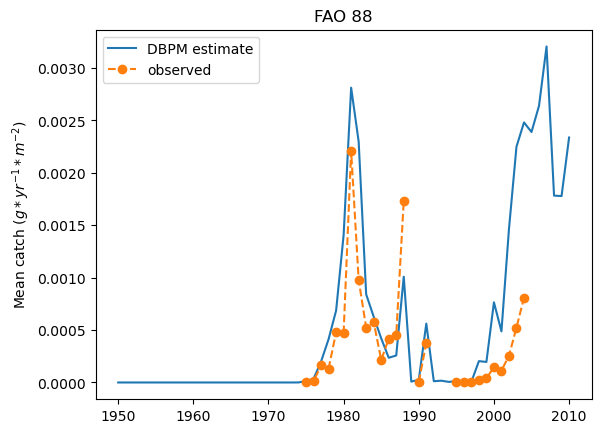

In [215]:
fig = plt.figure()
ax = fig.add_subplot(111)
mean_catch_dbpm.plot(x = 'year', y = 'mean_catch', ax = ax, label = 'DBPM estimate')
hist_catch.plot(x = 'year', y = 'catch_g_m2', ax = ax, ls = '--', marker = 'o', 
                label = 'observed')
plt.ylabel('Mean catch ($g*yr^{-1}*m^{-2}$)')
plt.xlabel(None)
plt.title(region.replace('-', ' ').upper())

In [7]:
tot_catch_pred = ((catch_pred*gridded_params['log_size_increase']).
                  sum(('size_class', 'lat', 'lon')))

tot_catch_det = ((catch_det*gridded_params['log_size_increase']).
                  sum(('size_class', 'lat', 'lon')))

total_catch = tot_catch_det+tot_catch_pred

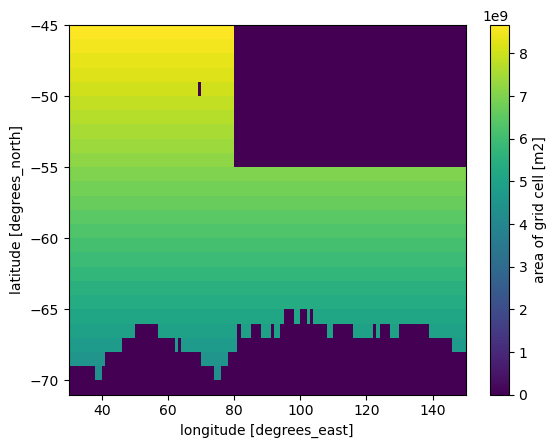

In [114]:
area = xr.open_zarr(glob(os.path.join(base_folder, 'gridded', model_res, '*areacello*'))[0])['cellareao']
weights = area.fillna(0)
weights.plot()

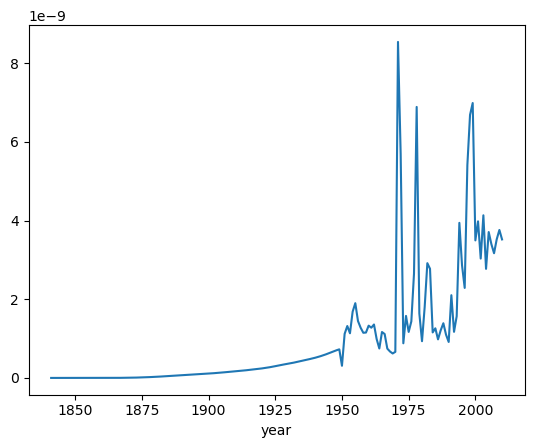

In [76]:
# tcp_map = ((catch_pred*gridded_params['log_size_increase']).sum(('size_class')))
tcp_map_den = tcp_map/area
tcp_map_den.sum(('lat', 'lon')).groupby('time.year').mean('time').plot()

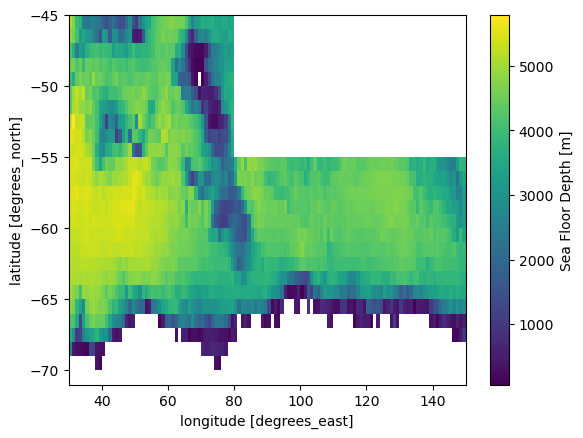

In [60]:
depth = xr.open_zarr(glob(os.path.join(base_folder, 'gridded', model_res, '*obsclim_deptho*'))[0])['deptho']
depth.plot()

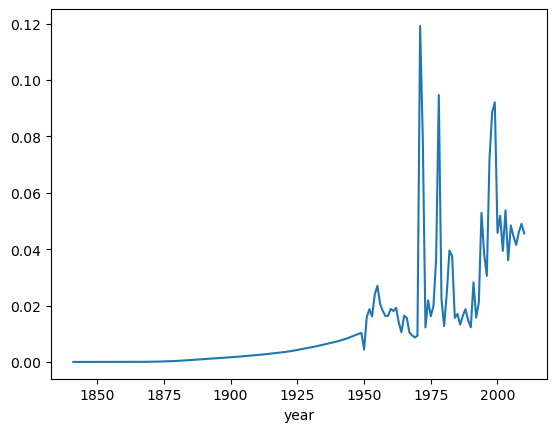

In [68]:
# tcp_map = ((catch_pred*gridded_params['log_size_increase']).sum(('size_class')))
# tcp_map_den = tcp_map/depth
tcp_map_den.sum(('lat', 'lon')).groupby('time.year').mean('time').plot()

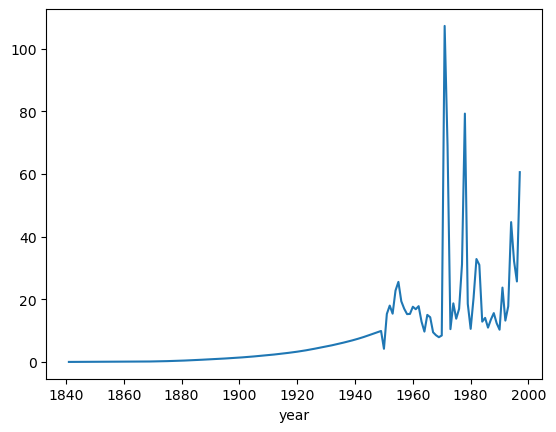

In [8]:
total_catch.groupby('time.year').mean('time').plot()

## Calculate total biomass for `predators` and `detritivores` 

In [90]:
tot_pred_bio = ((predators.isel(size_class = slice(gridded_params['ind_min_pred_size'], 
                                                  None))*
                gridded_params['log_size_increase']*size_bin_vals).
                sum(('size_class', 'lat', 'lon')))

tot_pred_det = (detritivores.isel(size_class = 
                                  slice(gridded_params['ind_min_detritivore_size'], 
                                        None))*gridded_params['log_size_increase']*
                size_bin_vals).sum(('size_class', 'lat', 'lon'))